In [28]:
import numpy as np
import time
import matplotlib
from matplotlib import animation, rc
import matplotlib.pyplot as plt
import cmath
from scipy.sparse import diags, linalg

In [26]:
class KronigPenney : 
    def __init__(self) : 
        self.a = 1.0                             # size of unit cell - lattice spacing
        self.V_0 = -5.0                          # height of potential barrier
        self.Delta = 0.2                         # width of potential barrier

    def solve_for_k(self, E):              # to solve 2x2 eigenvalue problem
        # E is the desired enegy (input)
        # k is a list of the two solutions
        q = np.sqrt(2 * E)
        kappa = np.sqrt(2 * (E - self.V_0))
        i = 1.0j
        T = np.zeros((2,2),dtype=complex)
        T[0,0] = ( np.exp(i * q * (self.a - self.Delta)) / (4 * q * kappa) *
            ( np.exp(i * kappa * self.Delta)  * (q + kappa)**2 -
              np.exp(-i * kappa * self.Delta) * (q - kappa)**2   ) )
        T[1,1] = T[0,0].conj()
        T[0,1] = ( -i * np.exp(i * q * (self.a - self.Delta)) / (2 * q * kappa) *
            (q**2 - kappa**2) * np.sin(kappa * self.Delta)  )
        T[1,0] = T[0,1].conj()

        # solve quadratic determinantal equation
        k = np.zeros(2, dtype=complex)
        b = - (T[0,0] + T[1,1])
        c = (T[0,0] * T[1,1] - T[0,1] * T[1,0])
        k[0] = (- b + np.sqrt(b**2 - 4*c)) / 2.0
        k[1] = (- b - np.sqrt(b**2 - 4*c)) / 2.0
        
        #k,v = np.linalg.eig(T)
        k = np.log(k) / (i*self.a)
        return k

    def compute_bands(self, dE, steps):
        # dE = step size in E for search
        # steps = number of steps
        E_values = np.zeros( (steps,2) )
        rq_values = np.zeros( (steps,2) )
        E = dE
        for step in range(steps):
            q = self.solve_for_k(E)
            for j in range(2):
                rq = q[j].real
                if rq > 0.0 and rq < np.pi / self.a:
                    rq_values[step,0] = rq
                    rq_values[step,1] = -rq
                    E_values[step,0] = E
                    E_values[step,1] = E
            E += dE
        return rq_values, E_values

In [44]:
class Wavepacket : 

    def __init__(self, N=6000, L=1000., dt=0.1, gaussian=False, kronig_penney = True): #Add a Kronig Penney potential option

        self.h_bar = 1.0             # Planck's constant / 2pi in natural units
        self.mass = 1.0              # particle mass in natural units

        # The spatial grid
        self.N = N                   # number of interior grid points
        self.L = L                   # system extends from x = 0 to x = L
        self.dx = L / float(N + 1)   # grid spacing
        self.dt = dt                 # time step

        # The potential V(x)
        self.V_0 = 0.5               # height of potential barrier
        self.V_width = 10.0          # width of potential barrier
        self.V_center = 0.75 * L     # center of potential barrier
        self.gaussian = gaussian     # True = Gaussian potential, False = KP or step potential

        self.KP = kronig_penney                  # True = Kronigpenney potenial, False = gaussian or step
        self.KP_space = 100.0
        
        # Initial wave packet
        self.x_0 = L / 4.0           # location of center
        self.E = 1.0                 # average energy
        self.sigma_0 = L / 10.0      # initial width of wave packet
        self.psi_norm = 1.0          # norm of psi
        self.k_0 = 0.0               # average wavenumber
        self.velocity = 0.0          # average velocity
        self.t = 0.0                 # time
        self.psi = np.zeros(N, dtype=complex) # complex wavefunction        
        self.x = np.arange(self.N) * self.dx # vector of grid points

        # initialize the packet
        self.k_0 = np.sqrt(2*self.mass*self.E - self.h_bar**2 / 2 / self.sigma_0**2) / self.h_bar
        self.velocity = self.k_0 / self.mass
        self.psi_norm = 1 / np.sqrt(self.sigma_0 * np.sqrt(np.pi))
        exp_factor = np.exp( - (self.x - self.x_0)**2 / (2 * self.sigma_0**2))
        # Wavefunction: 
        self.psi = (np.cos(self.k_0 * self.x) + 1j * np.sin(self.k_0 * self.x)) * exp_factor * self.psi_norm
        # wavefunction for simplified Crank-Nicholson : 
        self.chi = np.zeros(N, dtype=complex)

        # elements of tridiagonal matrix Q = (1/2)(1 + i dt H / (2 hbar))
        self.a = np.full( self.N-1, - 1j * self.dt * self.h_bar / (8 * self.mass * self.dx**2) )
        self.b = 0.5 + 1j * self.dt / (4 * self.h_bar) * (self.V(self.x) + self.h_bar**2 / (self.mass * self.dx**2))
        self.c = np.full( self.N-1, - 1j * self.dt * self.h_bar / (8 * self.mass * self.dx**2) )

    def V(self, x):
        if self.gaussian and self.KP:
            raise ValueError("gaussian = kronig_penney = True. Select only one or select neither for step potential.")
        elif self.gaussian:
            half_width = np.absolute(0.5 * self.V_width)
            return self.V_0 * np.exp(-(x - self.V_center)**2 / (2 * half_width**2))
        elif self.KP:
            x_cell = x % (self.V_width + self.KP_space) #Position within the barrier region
            return np.where(x_cell < self.V_width, self.V_0, 0.0)
        else:
            half_width = np.absolute(0.5 * self.V_width)
            return np.where( np.absolute(x - self.V_center) <= half_width, self.V_0, 0.0)


    def step_psi(self):
        T = diags([ self.b, self.a, self.c], [0,-1,1], format = 'csc')
        chi = linalg.spsolve(T,self.psi)
        self.psi = chi - self.psi
        return self.psi
        
class WavepacketFFT( Wavepacket) : 

    def __init__( self, N=128, L=100., dt=0.1 ):
        Wavepacket.__init__(self, N,L,dt)
        # precomputed phase rotation from kinetic energy
        self.T_exp_factor = np.zeros(N,dtype=complex)
        # precomputed phase rotation from kinetic energy
        self.V_exp_factor = np.zeros(N,dtype=complex)
        # initialize the phase rotation factors
        j = np.arange(N)
        p = np.where( j < N//2, j, j-N) * self.h_bar * 2 * np.pi/L        
        theta = - p**2 / (2 * self.mass) / self.h_bar * self.dt
        self.T_exp_factor = np.cos(theta) + 1j * np.sin(theta)
        # potential factor exp[-iV(x)/(2h_bar) dt]
        theta = - self.V(self.x) / 2.0 / self.h_bar * self.dt
        self.V_exp_factor = np.cos(theta) + 1j * np.sin(theta)


    def step_psi(self ):
        # first half of potential phase rotation
        self.psi *= self.V_exp_factor
        # FFT to momentum space
        psik = np.fft.fft(self.psi)
        # kinetic phase rotation
        psik *= self.T_exp_factor
        # FFT back to position space
        self.psi = np.fft.ifft(psik)
        # second half of potential phase rotation
        self.psi *= self.V_exp_factor
        self.t += self.dt
        return self.psi

In [45]:
class Animator :
    def __init__(self, wavepacket=None):
        self.avg_times = []
        self.wavepacket = wavepacket       
        self.t = 0.
        self.fig, self.ax = plt.subplots()

        self.myline = plt.axvline( x=(self.wavepacket.V_center - 0.5 * self.wavepacket.V_width)/ self.wavepacket.dx,
                                   color='r'
            )
        self.myline = plt.axvline( x=(self.wavepacket.V_center + 0.5 * self.wavepacket.V_width)/ self.wavepacket.dx,
                                   color='r'
            )
        self.ax.set_ylim(0,0.5)
        initvals = np.absolute(self.wavepacket.psi)
        self.line, = self.ax.plot(initvals)
        

    def update(self, data) :
        self.line.set_ydata(data)
        return self.line,
        
    def time_step(self):
        self.wavepacket.psi = self.wavepacket.step_psi()
        self.t += self.wavepacket.dt;
        yield np.absolute(self.wavepacket.psi)

    def animate(self) :
        self.ani = animation.FuncAnimation( self.fig,        # Animate our figure
                                            self.update,     # Update function draws our data
                                            self.time_step,  # "frames" function does the time step, each iteration
                                            interval=100,     # 50 ms between iterations
                                            blit=False,       # don't blit anything
                                            cache_frame_data=False
                                            )

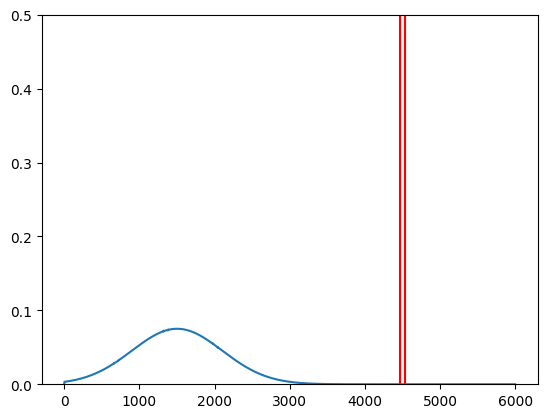

In [46]:
wavepacket = Wavepacket()
animator = Animator(wavepacket=wavepacket)
animator.animate()